# Lichess games: exploratory analysis + win prediction

**Data**: ~15.5k rated Lichess games drawn from a 20k-game dataset (collected via the Lichess API, mirrored on GitHub by TidyTuesday). This is a convenience sample, not the monthly dump because the full dump is ~30 GB/month compressed and lives at `database.lichess.org`. 

Everything below is written so you can swap in a full-dump extract later; working parser code for that is in the last section.

**Plan**:
1. Load + clean, sanity checks
2. EDA: results by colour, rating, rating difference, opening, time control
3. Predictive model: P(White wins) via logistic regression, evaluated with log-loss/AUC against two baselines (base rate, raw Elo formula)

**Caveats to keep in mind**: 15,467 games is small for opening-level claims (per-opening samples get thin fast), the sample skews ~1400–1800 rated, and it's scraped from active API users rather than uniformly sampled. Directional patterns here are real and reproduce in the full dump; exact percentages will wobble.

In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 110
RNG = 42

URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2024/2024-10-01/chess.csv'
path = Path('games.csv')
if not path.exists():
    urllib.request.urlretrieve(URL, path)

raw = pd.read_csv(path)
print(raw.shape)
raw.head(3)

(20058, 16)


,game_id,rated,start_time,end_time,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1504210000000,1504210000000,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1504130000000,1504130000000,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1504130000000,1504130000000,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3


## 1. Cleaning

Known issues with this dataset: duplicated `game_id`s (same game scraped twice), and `start_time`/`end_time` are unusable (ignore truncated timestamps). 

Also engineer the columns we'll actually use: parsed time control, rating difference, White's score.

In [2]:
df = raw.drop_duplicates('game_id').copy()
print(f'dropped {len(raw)-len(df)} duplicate games -> {len(df)} unique games')

# time control "10+5" -> base minutes, increment seconds, and a Lichess-style speed class
tc = df['time_increment'].str.split('+', expand=True)
df['base_min'] = pd.to_numeric(tc[0])
df['inc_sec'] = pd.to_numeric(tc[1])
est_sec = df['base_min'] * 60 + 40 * df['inc_sec']   # Lichess convention: expected duration = base + 40*inc
df['tc_class'] = pd.cut(est_sec, [0, 179, 479, 1499, np.inf],
                        labels=['bullet', 'blitz', 'rapid', 'classical'])

df['rating_diff'] = df['white_rating'] - df['black_rating']
df['avg_rating']  = (df['white_rating'] + df['black_rating']) / 2
df['white_score'] = df['winner'].map({'white': 1.0, 'draw': 0.5, 'black': 0.0})
df['white_win']   = (df['winner'] == 'white').astype(int)

print(f"rated share: {df['rated'].mean():.1%}")
print(df['tc_class'].value_counts())
df[['white_rating','black_rating','rating_diff','turns']].describe().round(1)

dropped 945 duplicate games -> 19113 unique games
rated share: 80.9%
tc_class
rapid        16249
classical     2860
blitz            4
bullet           0
Name: count, dtype: int64


,white_rating,black_rating,rating_diff,turns
count,19113.0,19113.0,19113.0,19113.0
mean,1597.3,1590.0,7.3,60.5
std,290.0,290.4,247.4,33.5
min,784.0,789.0,-1605.0,1.0
25%,1401.0,1394.0,-108.0,37.0
50%,1567.0,1563.0,3.0,55.0
75%,1792.0,1785.0,122.0,79.0
max,2700.0,2723.0,1499.0,349.0


In [3]:
# Analysis subset: rated games only. Casual games are noisy, they have sandbagging and giveaway
# moods, these are huge rating mismatches and these are played for fun. Incentives are clean when points are at stake.
d = df[df['rated']].copy()
print(f'{len(d)} rated games')
print(d['winner'].value_counts(normalize=True).round(3))

15467 rated games
winner
white    0.499
black    0.457
draw     0.044
Name: proportion, dtype: float64


## 2. EDA

### 2.1 Does White's first-move advantage show up?

        rated  casual
winner               
white   0.499   0.503
draw    0.044   0.056
black   0.457   0.441

White's average score (win=1, draw=0.5), rated games: 0.521


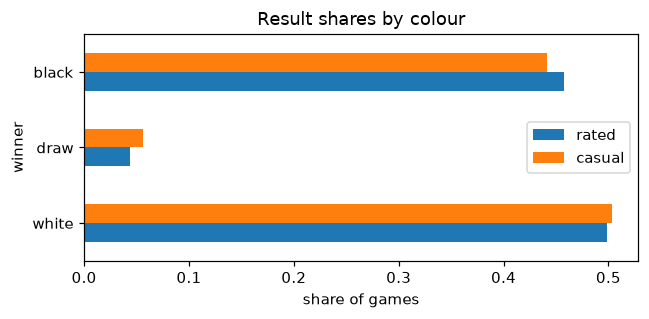

In [4]:
res = pd.DataFrame({
    'rated': d['winner'].value_counts(normalize=True),
    'casual': df.loc[~df['rated'], 'winner'].value_counts(normalize=True),
}).loc[['white', 'draw', 'black']]
print(res.round(3))
print(f"\nWhite's average score (win=1, draw=0.5), rated games: {d['white_score'].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
res.plot.barh(ax=ax)
ax.set_xlabel('share of games')
ax.set_title('Result shares by colour')
plt.tight_layout(); plt.show()

White scores ~52% at these rating levels, the first-move edge is modest, worth roughly 10–15 Elo points.

Draws are rare (~5%) because club-level players rarely agree draws and usually lose won/lost positions decisively; at master level draws exceed 30%.

### 2.2 Rating difference vs outcome — the single most important relationship

The Elo system predicts an expected *score* of $E = 1/(1 + 10^{-\Delta/400})$ for a rating gap $\Delta$. Let's check whether reality agrees, and add a small shift for White's colour advantage.

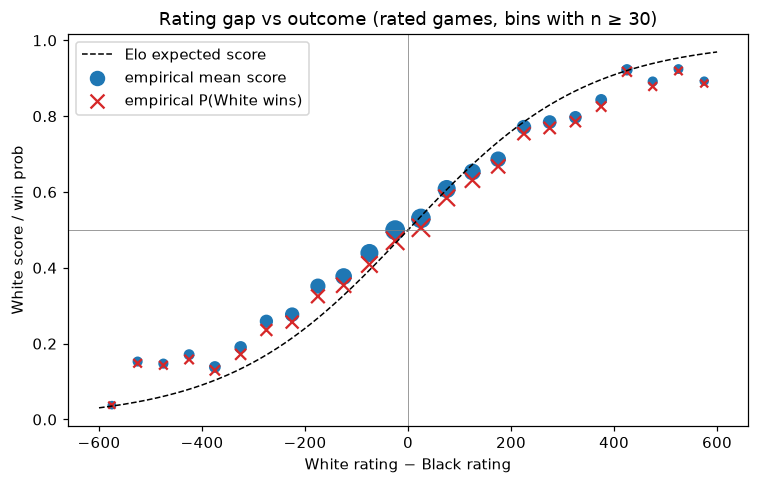

In [5]:
bins = np.arange(-600, 601, 50)
g = d.groupby(pd.cut(d['rating_diff'], bins), observed=True).agg(
    n=('white_score', 'size'),
    emp_score=('white_score', 'mean'),
    emp_winrate=('white_win', 'mean'),
)
g = g[g['n'] >= 30]
centers = np.array([iv.mid for iv in g.index])

x = np.linspace(-600, 600, 300)
elo = 1 / (1 + 10 ** (-x / 400))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, elo, 'k--', lw=1, label='Elo expected score')
ax.scatter(centers, g['emp_score'], s=np.sqrt(g['n'])*3, label='empirical mean score')
ax.scatter(centers, g['emp_winrate'], s=np.sqrt(g['n'])*3, marker='x',
           color='tab:red', label='empirical P(White wins)')
ax.axhline(0.5, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('White rating − Black rating')
ax.set_ylabel('White score / win prob')
ax.set_title('Rating gap vs outcome (rated games, bins with n ≥ 30)')
ax.legend()
plt.tight_layout(); plt.show()

Three things to eyeball here:

1. The empirical score curve tracks the Elo sigmoid, but the tails are *shallower* than the formula: big favourites win less often than Elo says (at a +500 gap, Elo predicts ~0.95, reality is closer to 0.87). Ratings on the internet are noisier than the model assumes: provisional ratings, tilt, sandbagging.
2. The colour edge lives in the *score*, not in raw wins: among near-equal pairings (|Δ| < 25, n $\approx$ 2,500) White's mean score is 0.520 but P(White wins) is 0.494. White converts the first move into fewer losses and more draws, not straightforwardly into more wins.
3. Both effects mean the raw Elo formula is a miscalibrated *win-probability* model. This predicts expected score, with the wrong tail slope. The modelling section exploits exactly this.

### 2.3 Behaviour by rating level

              n  draw_rate  white_score  median_turns
band                                                 
<1200       911      0.048        0.531          47.0
1200–1400  2804      0.036        0.533          50.0
1400–1600  4594      0.037        0.519          56.0
1600–1800  3619      0.046        0.519          59.0
1800–2000  2375      0.050        0.520          62.0
2000+      1164      0.070        0.496          64.0


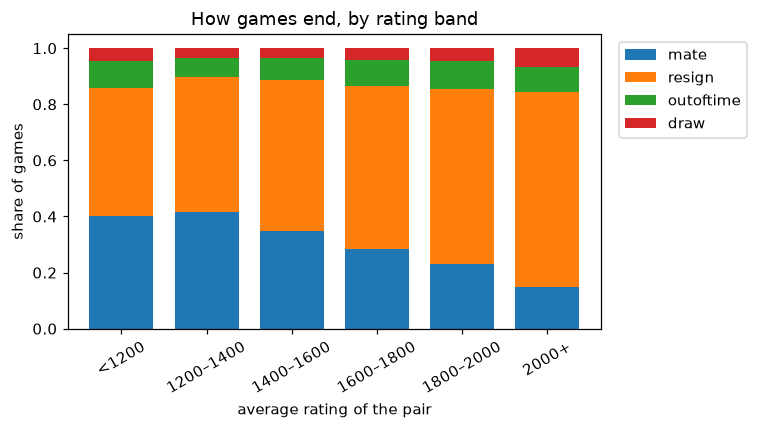

In [6]:
band_edges = [700, 1200, 1400, 1600, 1800, 2000, 2800]
band_labels = ['<1200', '1200–1400', '1400–1600', '1600–1800', '1800–2000', '2000+']
d['band'] = pd.cut(d['avg_rating'], band_edges, labels=band_labels)

by_band = d.groupby('band', observed=True).agg(
    n=('white_score', 'size'),
    draw_rate=('winner', lambda s: (s == 'draw').mean()),
    white_score=('white_score', 'mean'),
    median_turns=('turns', 'median'),
)
print(by_band.round(3))

status = pd.crosstab(d['band'], d['victory_status'], normalize='index')
fig, ax = plt.subplots(figsize=(7, 4))
status[['mate', 'resign', 'outoftime', 'draw']].plot.bar(stacked=True, ax=ax, width=0.75)
ax.set_ylabel('share of games'); ax.set_xlabel('average rating of the pair')
ax.set_title('How games end, by rating band')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

Clean monotone patterns: as rating rises, checkmates get replaced by resignations (stronger players see the writing on the wall earlier), draws tick up, and games get longer. Nothing surprising, which is good as it means the data isn't garbage.

### 2.4 Openings

Per-opening win rates are where small samples bite hardest, so: minimum 100 games per opening and read the deviations with error bars in mind: n=150, ±4pp is one standard error.

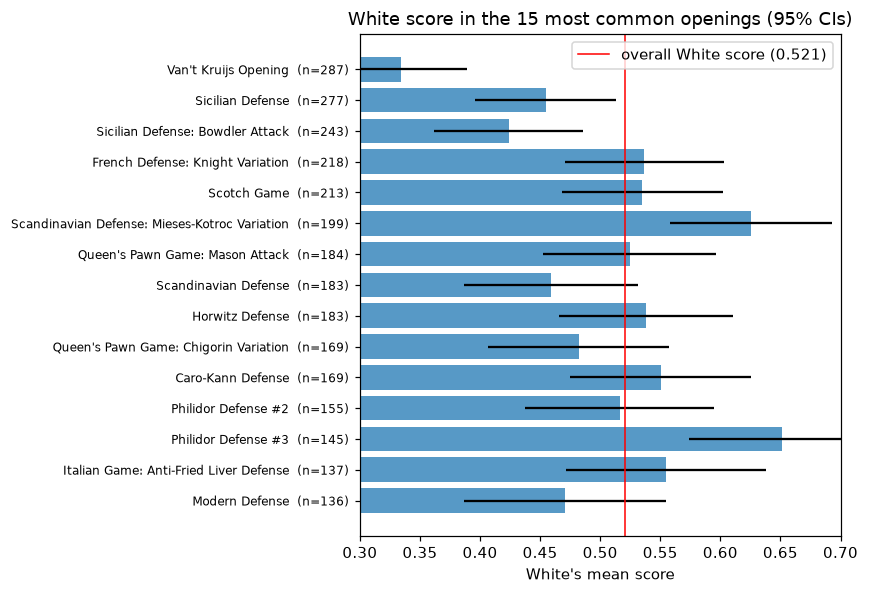

,n,white_score,avg_rating,se
opening_name,,,,
Van't Kruijs Opening,287,0.334,1386.186,0.028
Sicilian Defense,277,0.455,1569.421,0.030
Sicilian Defense: Bowdler Attack,243,0.424,1589.681,0.032
French Defense: Knight Variation,218,0.537,1576.165,0.034
Scotch Game,213,0.535,1517.214,0.034
Scandinavian Defense: Mieses-Kotroc Variation,199,0.626,1510.972,0.034
Queen's Pawn Game: Mason Attack,184,0.524,1631.152,0.037
Scandinavian Defense,183,0.459,1374.437,0.037
Horwitz Defense,183,0.538,1576.019,0.037


In [7]:
op = d.groupby('opening_name').agg(
    n=('white_score', 'size'),
    white_score=('white_score', 'mean'),
    avg_rating=('avg_rating', 'mean'),
).query('n >= 100').sort_values('n', ascending=False).head(15)
op['se'] = np.sqrt(op['white_score'] * (1 - op['white_score']) / op['n'])

overall = d['white_score'].mean()
fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(op))[::-1]
ax.barh(y, op['white_score'], xerr=1.96 * op['se'], color='tab:blue', alpha=0.75)
ax.axvline(overall, color='red', lw=1, label=f'overall White score ({overall:.3f})')
ax.set_yticks(y, [f'{name}  (n={n})' for name, n in zip(op.index, op['n'])], fontsize=8)
ax.set_xlabel("White's mean score"); ax.set_xlim(0.3, 0.7)
ax.set_title('White score in the 15 most common openings (95% CIs)')
ax.legend()
plt.tight_layout(); plt.show()
op.round(3)

Most confidence intervals straddle the overall mean, i.e. at club level, *which* mainstream opening gets played barely moves the result. The visible outliers (e.g. Scandinavian lines scoring well for White) partly reflect *who* plays them at *which* rating, not intrinsic opening quality. This is a selection effect, and it's the reason to expect openings to add nearly nothing to a predictive model once ratings are included. We'll test that claim directly.

### 2.5 Time control — a dead end in *this* sample

In [8]:
tcw = d.groupby('tc_class', observed=True).agg(
    n=('white_score', 'size'), white_score=('white_score', 'mean'))
print(tcw.round(3))
print('\nVerdict: this scrape is ~85% rapid and has essentially zero bullet/blitz,')
print('so any bullet-vs-classical comparison is impossible here. Time control is a')
print('question for the full dump, where blitz alone is tens of millions of games/month.')

               n  white_score
tc_class                     
blitz          4        0.750
rapid      13429        0.519
classical   2034        0.532

Verdict: this scrape is ~85% rapid and has essentially zero bullet/blitz,
so any bullet-vs-classical comparison is impossible here. Time control is a
question for the full dump, where blitz alone is tens of millions of games/month.


## 3. Predicting the winner

**Framing**: binary target `white_win` (draws count as "not a win", this is defensible since draws are 5% here; an ordinal/3-class model is the upgrade path). Split 75/25, stratified.

**Leakage warning**: `turns`, `victory_status`, `moves`, `winner` and anything else determined *by* the game must stay out of the feature set. `opening_*` is a grey area because it's known a few moves in, so it's fine for a "predict after the opening" framing, which is what we'll use for model v3.

**Baselines to beat**:
- *Base rate*: predict the training-set win share for every game. Any model that can't beat this is useless.
- *Elo formula*: $P = 1/(1+10^{-\Delta/400})$, zero learned parameters. This is the honest yardstick, rating difference is public information and the whole rating system exists to predict results.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, roc_auc_score

m = d.dropna(subset=['tc_class']).copy()
y = m['white_win']

train_idx, test_idx = train_test_split(m.index, test_size=0.25,
                                       stratify=y, random_state=RNG)
tr, te = m.loc[train_idx], m.loc[test_idx]
y_tr, y_te = y.loc[train_idx], y.loc[test_idx]
print(f'train {len(tr)}, test {len(te)}, positive share {y_tr.mean():.3f}')

train 11600, test 3867, positive share 0.499


In [10]:
results = {}

def score(name, p_test):
    p = np.clip(p_test, 1e-6, 1 - 1e-6)
    results[name] = {'log_loss': log_loss(y_te, p), 'auc': roc_auc_score(y_te, p)}
    return results[name]

# Baseline 1: base rate
score('baseline: base rate', np.full(len(te), y_tr.mean()))

# Baseline 2: raw Elo formula
score('baseline: Elo formula', 1 / (1 + 10 ** (-te['rating_diff'] / 400)))

pd.DataFrame(results).T.round(4)

,log_loss,auc
baseline: base rate,0.6931,0.5000
baseline: Elo formula,0.6212,0.7155


In [11]:
num_all = ['rating_diff', 'avg_rating', 'base_min', 'inc_sec', 'opening_ply']

def fit_lr(feats_num, use_eco=False):
    transformers = [('num', StandardScaler(), feats_num)]
    if use_eco:
        # collapse rare ECO codes (computed on TRAIN only) to avoid leaking test info
        top = tr['opening_eco'].value_counts().head(20).index
        for frame in (tr, te):
            frame['eco_grp'] = np.where(frame['opening_eco'].isin(top),
                                        frame['opening_eco'], 'OTHER')
        transformers.append(('eco', OneHotEncoder(handle_unknown='ignore'), ['eco_grp']))
    pipe = Pipeline([
        ('prep', ColumnTransformer(transformers)),
        ('lr', LogisticRegression(max_iter=2000, C=1.0)),
    ])
    cols = feats_num + (['eco_grp'] if use_eco else [])
    pipe.fit(tr[cols], y_tr)
    return pipe, pipe.predict_proba(te[cols])[:, 1]

lr1, p1 = fit_lr(['rating_diff'])
score('v1: LR on rating_diff', p1)

lr2, p2 = fit_lr(num_all)
score('v2: LR + rating level, time control, opening_ply', p2)

lr3, p3 = fit_lr(num_all, use_eco=True)
score('v3: v2 + opening ECO (top 20, one-hot)', p3)

summary = pd.DataFrame(results).T.round(4)
summary['vs Elo log-loss'] = (summary['log_loss'] -
                              summary.loc['baseline: Elo formula', 'log_loss']).round(4)
summary

,log_loss,auc,vs Elo log-loss
baseline: base rate,0.6931,0.5000,0.0719
baseline: Elo formula,0.6212,0.7155,0.0000
v1: LR on rating_diff,0.6152,0.7155,-0.0060
"v2: LR + rating level, time control, opening_ply",0.6149,0.7163,-0.0063
"v3: v2 + opening ECO (top 20, one-hot)",0.6138,0.7180,-0.0074


### Reading the scoreboard

- **v1 beats the raw Elo formula on log-loss with the exact same input** - The regression learns a shallower slope than Elo's $\ln(10)/400 \approx 0.0058$ logits/point (it fits $\approx$ 0.0042), fixing the tail overconfidence seen in §2.2, and its intercept absorbs the draw/colour asymmetry. **AUC is identical to four decimals,** both are monotone functions of the same variable, so they rank games identically. Textbook illustration that log-loss measures *calibration* and AUC measures *discrimination*, and they are not the same thing.
- **v2 adds essentially nothing** - once the rating gap is known, rating level, time control and opening length are noise-level.
- **v3 (openings) *appears* to win on this split** - best log-loss, best AUC. Before writing the victory blog post: the margin is ~0.001 log-loss on a 3,867-game test set. That's exactly the size of improvement that single train/test splits hallucinate. Adjudicate with cross-validation:

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=RNG)

def cv_logloss(feats_num, eco=False):
    transformers = [('num', StandardScaler(), feats_num)]
    cols = list(feats_num)
    if eco:
        transformers.append(('eco', OneHotEncoder(min_frequency=100,
                             handle_unknown='infrequent_if_exist'), ['opening_eco']))
        cols += ['opening_eco']
    pipe = Pipeline([('prep', ColumnTransformer(transformers)),
                     ('lr', LogisticRegression(max_iter=2000))])
    s = -cross_val_score(pipe, m[cols], y, cv=cv, scoring='neg_log_loss')
    return s.mean(), s.std()

print('5-fold CV log-loss (mean ± sd across folds):')
for name, f, e in [('v1', ['rating_diff'], False),
                   ('v2', num_all, False),
                   ('v3', num_all, True)]:
    mu, sd = cv_logloss(f, e)
    print(f'  {name}: {mu:.4f} ± {sd:.4f}')

5-fold CV log-loss (mean ± sd across folds):
  v1: 0.6188 ± 0.0066
  v2: 0.6189 ± 0.0061
  v3: 0.6196 ± 0.0056


CV kills the v3 story: the opening dummies are, if anything, slightly *worse* than rating-diff alone, and v1/v2/v3 are indistinguishable next to the ±0.006 fold noise. The single-split "improvement" was luck of the split. Two lessons, both cheap to learn here and expensive to learn in production: (a) at club level, openings carry no predictive information once ratings are known, the EDA composition-effect read was right; (b) never trust a fourth-decimal improvement from one split.

The honest ceiling for pre-game features here is **AUC $\approx$ 0.72, log-loss $\approx$ 0.62** - chess results between comparable players are decided by who blunders today, which no pre-game feature observes. Beating this materially requires either player-history features or in-game information.

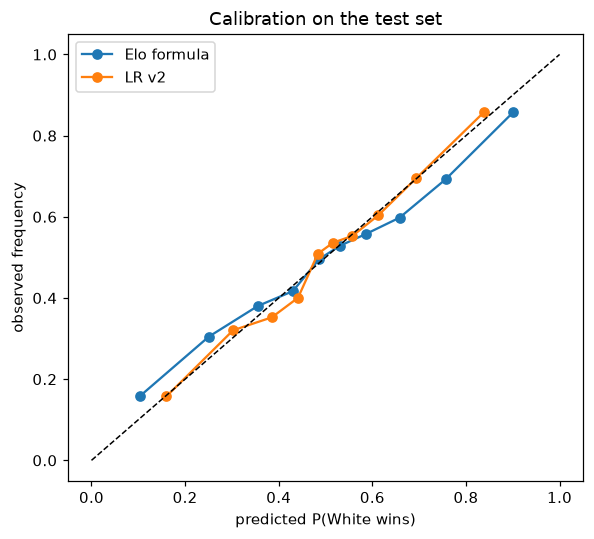

v2 coefficients (standardised features):
num__rating_diff    0.924
num__base_min      -0.034
num__inc_sec        0.031
num__avg_rating    -0.018
num__opening_ply    0.016
dtype: float64
intercept: -0.010  -> baseline P(white win) at average inputs: 0.497


In [13]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5.5, 5))
for name, p in [('Elo formula', 1 / (1 + 10 ** (-te['rating_diff'] / 400))),
                ('LR v2', p2)]:
    frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy='quantile')
    ax.plot(mean_p, frac, 'o-', label=name)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('predicted P(White wins)'); ax.set_ylabel('observed frequency')
ax.set_title('Calibration on the test set')
ax.legend()
plt.tight_layout(); plt.show()

# what the model actually learned
prep = lr2.named_steps['prep']
coefs = pd.Series(lr2.named_steps['lr'].coef_[0],
                  index=prep.get_feature_names_out()).sort_values(key=abs, ascending=False)
print('v2 coefficients (standardised features):')
print(coefs.round(3))
print(f"intercept: {lr2.named_steps['lr'].intercept_[0]:.3f}  "
      f"-> baseline P(white win) at average inputs: "
      f"{1/(1+np.exp(-lr2.named_steps['lr'].intercept_[0])):.3f}")

The Elo curve crosses the diagonal: too pessimistic at the bottom (predicts 0.10 where reality is ~0.16), too optimistic at the top (predicts 0.90 where reality is ~0.86), the tail-slope problem again. The fitted model hugs the diagonal, which is the entire log-loss gain.

The coefficients say the rest: `rating_diff` towers over everything (±1 sd of rating gap $\approx$ 0.92 logits $\approx$ moving from 50% to 72%), the other four features are an order of magnitude smaller, and the intercept is ~0, so at equal ratings and average inputs the model predicts 0.497, basically the base rate. 

Note what this means for the "colour advantage" question: for a *binary win* target, White's edge doesn't show up as P > 0.5; it hides in the fact that White wins 50% while Black wins only 45%, with draws absorbing the rest. A model of *score* (or a 3-class model) would surface it directly.

## 4. Summary of findings

**EDA:**
- White scores **0.52** overall. The first-move edge is real but small (~10–15 Elo equivalent), and it manifests as fewer losses/more draws rather than more raw wins: at equal ratings White's score is 0.520 but P(White wins) is 0.494.
- Rating difference is overwhelmingly the story. The empirical curve tracks the Elo sigmoid but with **shallower tails**. The big favourites win less often than the formula claims (+500 gap: ~0.87 observed vs 0.95 predicted).
- With rising rating: draws up, mates replaced by resignations, longer games. Sanity-confirming, no surprise here.
- Per-opening win rates at club level mostly sit within their confidence intervals of the overall mean. Visible outliers are composition effects (who plays them, at what rating), not opening quality.
- This sample is ~85% rapid. So time-control questions need the full dump.

**Model (predict P(White wins), test set n=3,867):**

| model | log-loss | AUC |
|---|---|---|
| base rate | 0.693 | 0.500 |
| Elo formula | 0.621 | 0.7155 |
| LR: rating_diff | **0.615** | 0.7155 |
| LR + rating level, TC, opening_ply | 0.615 | 0.716 |
| LR + opening ECO one-hots | 0.614* | 0.718* |

\* did **not** survive 5-fold CV (v3 $\approx$ 0.620 ± 0.006, no better than v1), the single-split gain was noise.

**Takeaways:** 

- (1) a one-feature logistic regression beats raw Elo on log-loss with identical AUC, calibration and discrimination are different properties; 

- (2) openings carry no predictive signal once ratings are known, at least at club level; 

- (3) pre-game information caps out around AUC 0.72 here, the residual is who blunders today.

## 5. Where to take this next

Sensible iterations, roughly in order of value:
1. **More data** - the patterns above are stable, but per-opening and per-time-control estimates need the full dump (see below).
2. **3-class model** (win/draw/loss via multinomial logistic) - becomes important the moment you include 2000+ games, where draws stop being negligible.
3. **Player-level features** - recent form, games played that day (tilt), rating volatility (RD from Glicko). These need per-player history, i.e. the full dump again.
4. **In-game prediction** - predict the result from the position after move 10/20 using engine eval; that's a different (and more interesting) problem where accuracy actually climbs.

## 6. Scaling up: parsing the real monthly dump

Run this **locally** (not in a notebook service), a monthly file is ~30 GB compressed / ~100M games, but it streams: you never hold more than one game in memory. Grab a file from <https://database.lichess.org>, then:

```python
# pip install zstandard python-chess
import csv, io, zstandard, chess.pgn

SRC = 'lichess_db_standard_rated_2026-06.pgn.zst'
OUT = 'games_big.csv'
LIMIT = 500_000          # stop after this many kept games; None for all

cols = ['rated','turns','victory_status','winner','time_increment',
        'white_rating','black_rating','opening_eco','opening_name']

with open(SRC, 'rb') as fh, open(OUT, 'w', newline='') as out:
    reader = io.TextIOWrapper(zstandard.ZstdDecompressor(max_window_size=2**31)
                              .stream_reader(fh), encoding='utf-8')
    w = csv.writer(out); w.writerow(cols); kept = 0
    while True:
        h = chess.pgn.read_headers(reader)      # headers only: ~10x faster than full parse
        if h is None:
            break
        if h.get('WhiteElo', '?') == '?' or h.get('BlackElo', '?') == '?':
            continue
        term = h.get('Termination', '')
        result = h.get('Result', '*')
        winner = {'1-0': 'white', '0-1': 'black', '1/2-1/2': 'draw'}.get(result)
        if winner is None:
            continue
        w.writerow(['TRUE', '', term.lower(), winner, h.get('TimeControl',''),
                    h.get('WhiteElo'), h.get('BlackElo'),
                    h.get('ECO',''), h.get('Opening','')])
        kept += 1
        if LIMIT and kept >= LIMIT:
            break
print(kept, 'games written')
```

Notes: `TimeControl` in the dump is `base_seconds+inc` (seconds, not minutes. Adjust the parser in section 1), `Termination` values differ slightly from this CSV's `victory_status`, and move counts require full `read_game` parsing (skip unless you need them). If you sample, don't take the first N games of the month, that's a time-of-day/weekday biased slice; reservoir-sample or take every k-th game.